In [36]:
# Configuration GitHub
from getpass import getpass
import os
import sys
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [ ]:
# Vos informations GitHub
GITHUB_USERNAME = "oussamalakhili5"  # Remplacez par votre username
REPO_NAME = "instagram-reach-analysis"

In [ ]:
# Configurer Git
!git config --global user.email "oussama.lakhili@outlook.fr"
!git config --global user.name "Oussama Lakhili"

In [ ]:

# ✅ CORRECT : getpass avec un simple message, SANS le token
token = getpass('Entrez votre token GitHub (il restera invisible) : ')
os.environ['GITHUB_TOKEN'] = token


In [ ]:
# Cloner le repository
!git clone https://{token}@github.com/oussamalakhili5/instagram-reach-analysis.git

# Entrer dans le dossier
%cd instagram-reach-analysis

print("✅ Repository cloné avec succès !")

In [2]:
# Créer la structure du projet
!mkdir -p data
!mkdir -p notebooks
!mkdir -p images

# Afficher la structure créée
print("📁 Structure du projet créée :")
!ls -la

print("\n✅ Étape 1 terminée ! Structure créée avec succès !")

A subdirectory or file -p already exists.
Error occurred while processing: -p.


📁 Structure du projet créée :


A subdirectory or file -p already exists.
Error occurred while processing: -p.



✅ Étape 1 terminée ! Structure créée avec succès !


'ls' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
# Créer le fichier .gitignore
%%writefile .gitignore
__pycache__/
*.pyc
.ipynb_checkpoints/
token.txt
*.csv
.DS_Store
*.pdf

print("✅ Étape 2 terminée ! Fichier .gitignore créé !")

In [ ]:
# Créer un README professionnel
%%writefile README.md
# 📱 Instagram Reach Analysis

## 🎯 Objectif du Projet
Analyse complète de la portée des posts Instagram pour comprendre les facteurs qui influencent l'engagement et prédire la performance future des publications.

## 📊 Méthodologie (Processus KDD)
1. **Data Cleaning** : Nettoyage et préparation des données
2. **EDA** : Analyse exploratoire avec visualisations
3. **Clustering** : Segmentation des posts avec K-Means
4. **Prédiction** : Prévision de la portée avec Random Forest

## 🛠️ Technologies Utilisées
- Python 3.x
- Pandas & NumPy pour la manipulation des données
- Matplotlib & Seaborn pour la visualisation
- Scikit-learn pour le Machine Learning
- WordCloud pour l'analyse textuelle

## 📈 Résultats Clés
- Identification de clusters de posts (Viraux, Moyens, Faibles)
- Modèle prédictif pour estimer la portée future
- Recommandations concrètes pour améliorer l'engagement

## 📁 Structure du Projet

In [ ]:
# Vérifier l'état des fichiers
print("📋 Fichiers modifiés :")
!git status

# Ajouter tous les fichiers
!git add .

# Créer le commit
!git commit -m "📝 Initialisation du projet : structure, README et .gitignore"

# Pousser sur GitHub
!git push origin main

print("\n✅ Étape 4 terminée ! Premier commit envoyé sur GitHub !")

# ***🎯 IMPORTATION DES BIBLIOTHÈQUES***




In [33]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.cluster import KMeans

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)


# ***🎯CHARGER ET EXPLORER LES DONNÉES***

In [8]:
df = pd.read_csv("../data/Instagram data.csv", encoding="latin-1")
df.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...
1,5394,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...
2,4021,2085,1188,0,533,41,11,1,131,62,12,Learn how to train a machine learning model an...,#data #datascience #dataanalysis #dataanalytic...
3,4528,2700,621,932,73,172,10,7,213,23,8,Heres how you can write a Python program to d...,#python #pythonprogramming #pythonprojects #py...
4,2518,1704,255,279,37,96,5,4,123,8,0,Plotting annotations while visualizing your da...,#datavisualization #datascience #data #dataana...


In [ ]:
# Informations sur le dataset
df.info()

# ***🎯NETTOYAGE DES DONNÉES***

In [9]:
# Vérifier les valeurs manquantes
print("Valeurs manquantes par colonne :")
df.isnull().sum()

Valeurs manquantes par colonne :


Impressions       0
From Home         0
From Hashtags     0
From Explore      0
From Other        0
Saves             0
Comments          0
Shares            0
Likes             0
Profile Visits    0
Follows           0
Caption           0
Hashtags          0
dtype: int64

In [10]:
# Supprimer les valeurs manquantes
df_clean = df.dropna()

# Vérifier les doublons
print(f"Doublons trouvés : {df_clean.duplicated().sum()}")

# Supprimer les doublons si nécessaire
df_clean = df_clean.drop_duplicates()

# Réinitialiser l'index
df_clean = df_clean.reset_index(drop=True)

# Afficher la forme finale
print(f"Forme du dataset nettoyé : {df_clean.shape}")

Doublons trouvés : 17
Forme du dataset nettoyé : (102, 13)


# ***🎯COMMIT DU NETTOYAGE***

In [ ]:
# Sauvegarder le dataset nettoyé dans le dossier data
df_clean.to_csv('data/Instagram_data_clean.csv', index=False)

# Vérifier les fichiers modifiés
!git status

In [ ]:
# Ajouter les fichiers modifiés
!git add .

# Créer le commit
!git commit -m "🧹 Nettoyage des données : suppression des doublons et valeurs manquantes"

# Pousser sur GitHub
!git push origin main

# ***🎯ANALYSE EXPLORATOIRE (EDA) - PARTIE 1***

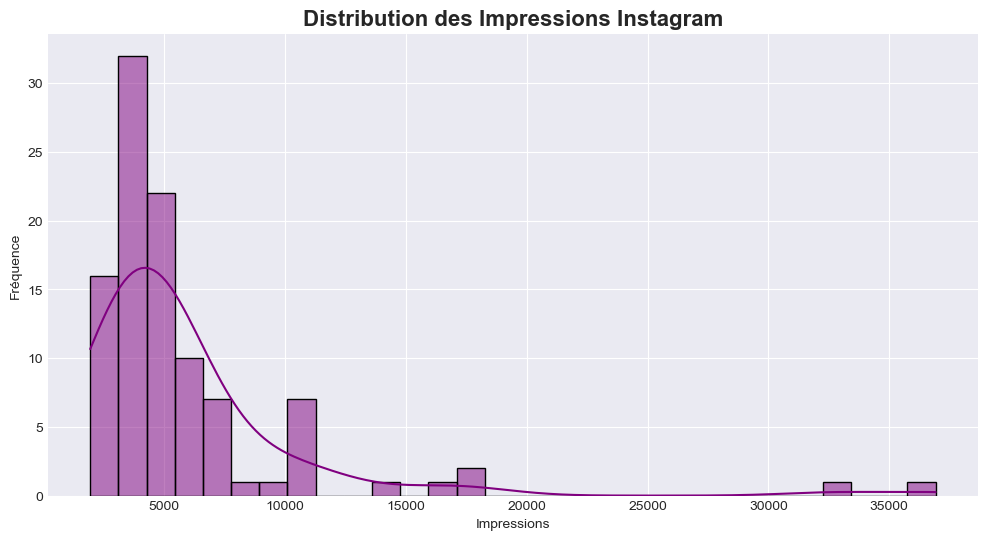

In [14]:
# Distribution des Impressions
plt.figure(figsize=(12, 6))
sns.histplot(df_clean['Impressions'], bins=30, kde=True, color='purple')
plt.title('Distribution des Impressions Instagram', fontsize=16, fontweight='bold')
plt.xlabel('Impressions')
plt.ylabel('Fréquence')
plt.savefig('../images/impressions_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ***🎯 ANALYSE EXPLORATOIRE (EDA) - PARTIE 2***

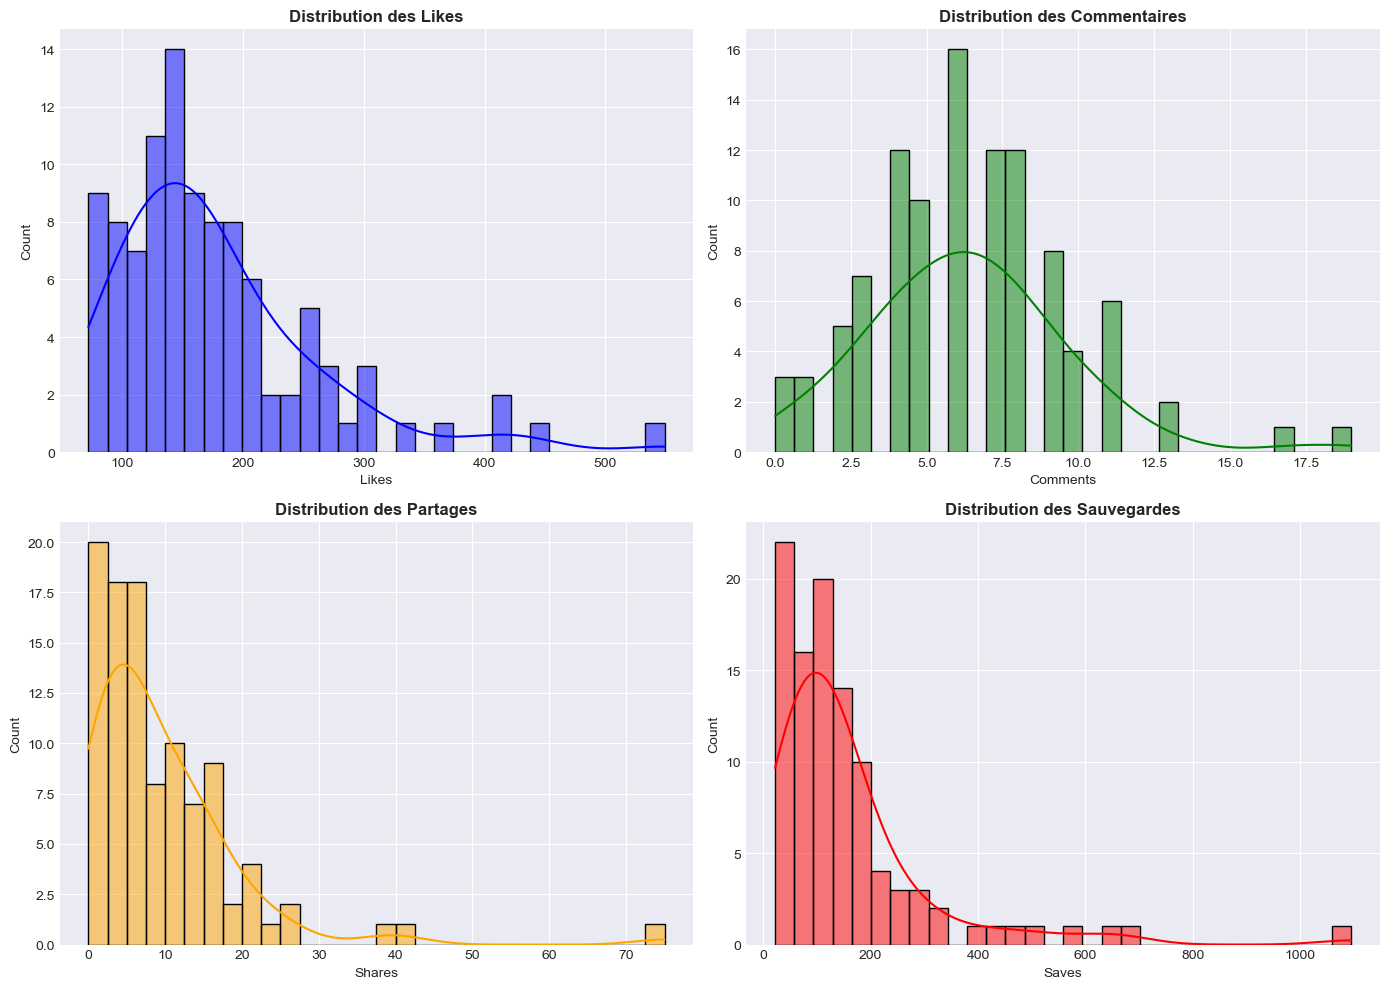

In [16]:
# Distribution des Likes, Comments, Shares et Saves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Likes
sns.histplot(df_clean['Likes'], bins=30, kde=True, color='blue', ax=axes[0, 0])
axes[0, 0].set_title('Distribution des Likes', fontweight='bold')

# Comments
sns.histplot(df_clean['Comments'], bins=30, kde=True, color='green', ax=axes[0, 1])
axes[0, 1].set_title('Distribution des Commentaires', fontweight='bold')

# Shares
sns.histplot(df_clean['Shares'], bins=30, kde=True, color='orange', ax=axes[1, 0])
axes[1, 0].set_title('Distribution des Partages', fontweight='bold')

# Saves
sns.histplot(df_clean['Saves'], bins=30, kde=True, color='red', ax=axes[1, 1])
axes[1, 1].set_title('Distribution des Sauvegardes', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/distributions_engagement.png', dpi=300, bbox_inches='tight')
plt.show()

# ***🎯 ANALYSE EXPLORATOIRE (EDA) - PARTIE 3***

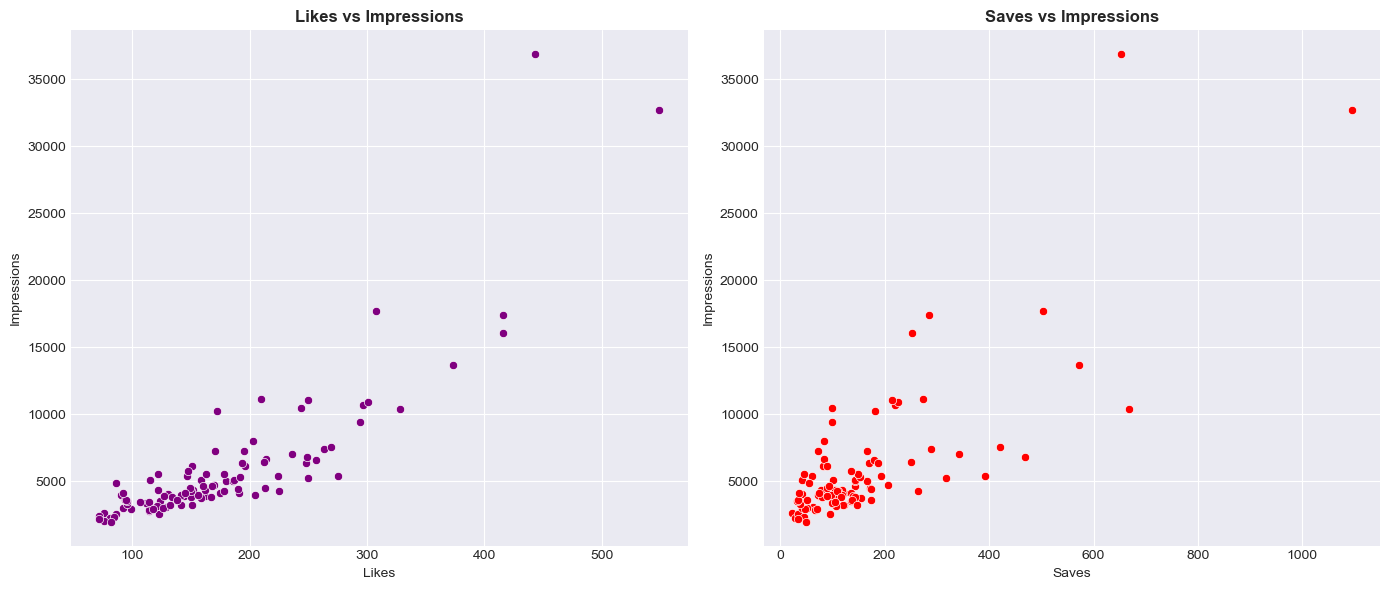

In [17]:
# Relations entre les variables
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Likes vs Impressions
sns.scatterplot(data=df_clean, x='Likes', y='Impressions', color='purple', ax=axes[0])
axes[0].set_title('Likes vs Impressions', fontweight='bold')

# Saves vs Impressions
sns.scatterplot(data=df_clean, x='Saves', y='Impressions', color='red', ax=axes[1])
axes[1].set_title('Saves vs Impressions', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/relations_impressions.png', dpi=300, bbox_inches='tight')
plt.show()

# ***🎯 ANALYSE EXPLORATOIRE (EDA) - PARTIE 4***

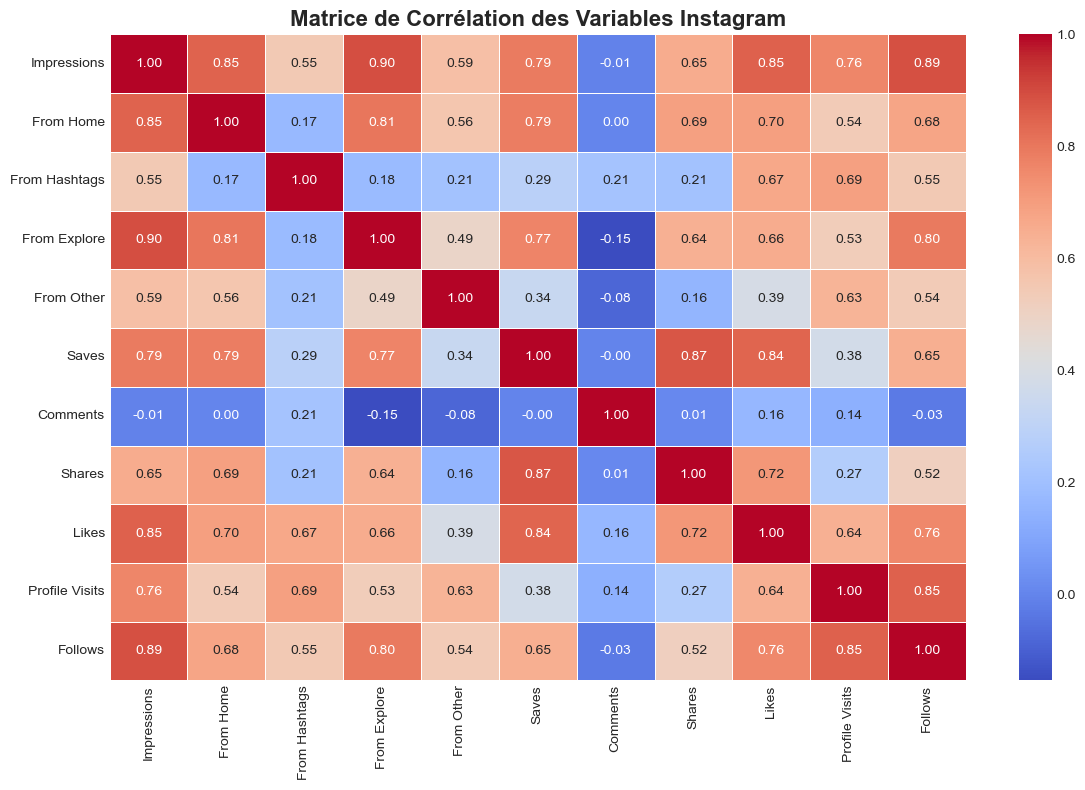

In [18]:
# Matrice de corrélation
plt.figure(figsize=(12, 8))

# Sélectionner uniquement les colonnes numériques
numeric_df = df_clean.select_dtypes(include=[np.number])

# Créer la heatmap
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matrice de Corrélation des Variables Instagram', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ***🎯 ANALYSE EXPLORATOIRE (EDA) - PARTIE 5***

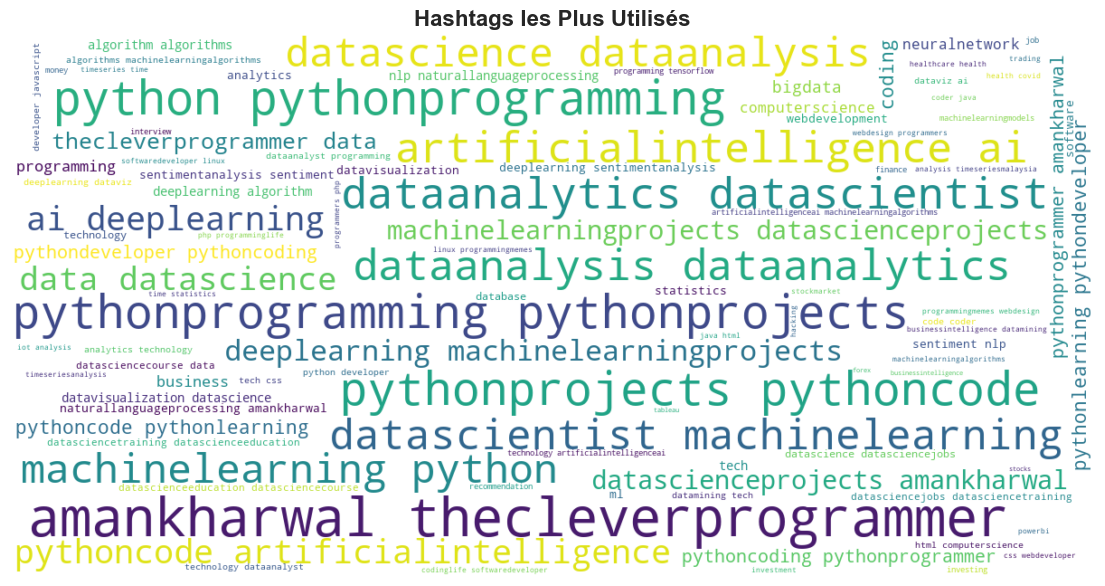

In [19]:
# Word Cloud des Hashtags
plt.figure(figsize=(14, 8))

# Combiner tous les hashtags
hashtags_text = ' '.join(df_clean['Hashtags'].dropna().astype(str))

# Créer le Word Cloud
wordcloud = WordCloud(width=1200, height=600,
                      background_color='white',
                      colormap='viridis',
                      max_words=100).generate(hashtags_text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Hashtags les Plus Utilisés', fontsize=16, fontweight='bold')
plt.savefig('../images/wordcloud_hashtags.png', dpi=300, bbox_inches='tight')
plt.show()

In [37]:
# Vérifier le nom exact de la colonne
print("Colonnes disponibles :")
print(df_clean.columns.tolist())

Colonnes disponibles :
['Impressions', 'From Home', 'From Hashtags', 'From Explore', 'From Other', 'Saves', 'Comments', 'Shares', 'Likes', 'Profile Visits', 'Follows', 'Caption', 'Hashtags', 'Cluster']


# ***🎯 ANALYSE EXPLORATOIRE (EDA) - PARTIE 6 (Word Cloud des Captions)***

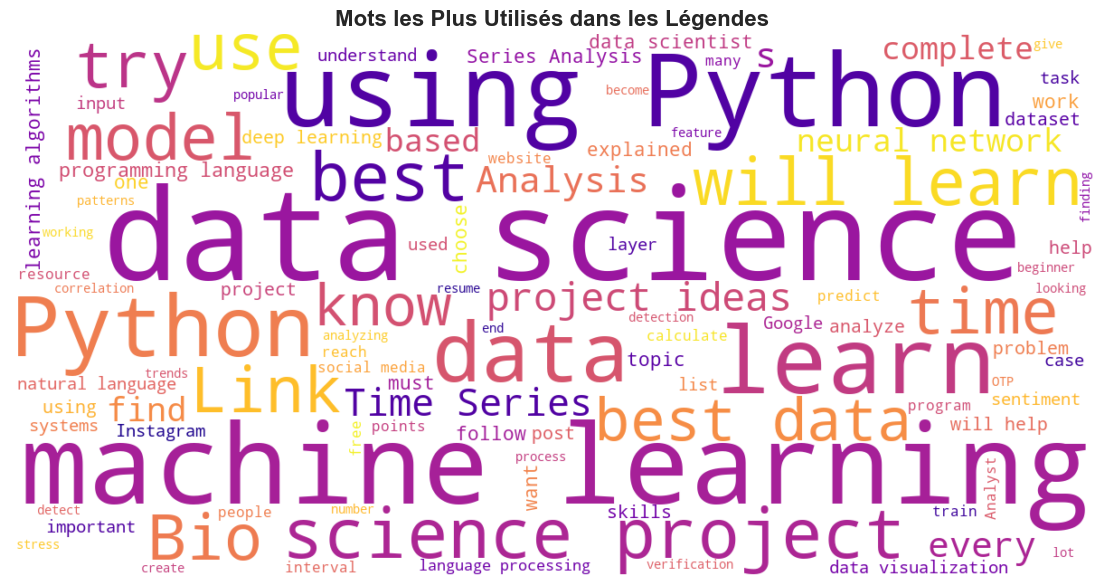

In [20]:
# Word Cloud des Captions (légendes)
plt.figure(figsize=(14, 8))

# Combiner toutes les légendes
captions_text = ' '.join(df_clean['Caption'].dropna().astype(str))

# Créer le Word Cloud
wordcloud_captions = WordCloud(width=1200, height=600,
                               background_color='white',
                               colormap='plasma',
                               max_words=100,
                               stopwords=STOPWORDS).generate(captions_text)

plt.imshow(wordcloud_captions, interpolation='bilinear')
plt.axis('off')
plt.title('Mots les Plus Utilisés dans les Légendes', fontsize=16, fontweight='bold')
plt.savefig('../images/wordcloud_captions.png', dpi=300, bbox_inches='tight')
plt.show()

# ***🎯 COMMIT DE L'EDA***

In [ ]:
# Ajouter les graphiques générés
!git add images/

# Créer le commit
!git commit -m "📈 Analyse exploratoire des données : distributions, corrélations et word clouds"

# Pousser sur GitHub
!git push origin main

# ***🎯 PRÉTRAITEMENT POUR LE MACHINE LEARNING***

In [21]:
# Sélectionner les colonnes numériques pour le clustering
features = ['Likes', 'Saves', 'Comments', 'Shares', 'Profile Visits', 'Follows']

# Créer un nouveau dataframe avec ces colonnes
X = df_clean[features]

# Afficher les 5 premières lignes
X.head()

,Likes,Saves,Comments,Shares,Profile Visits,Follows
0,162,98,9,5,35,2
1,224,194,7,14,48,10
2,131,41,11,1,62,12
3,213,172,10,7,23,8
4,123,96,5,4,8,0


In [22]:
# Standardisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir en DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

# Afficher les statistiques après standardisation
X_scaled_df.describe()

,Likes,Saves,Comments,Shares,Profile Visits,Follows
count,1.020000e+02,1.020000e+02,1.020000e+02,1.020000e+02,1.020000e+02,1.020000e+02
mean,1.393221e-16,-6.530724e-17,9.796086e-17,-4.571507e-17,2.612289e-17,-8.707632e-18
std,1.004938e+00,1.004938e+00,1.004938e+00,1.004938e+00,1.004938e+00,1.004938e+00
min,-1.237099e+00,-8.570272e-01,-1.929905e+00,-9.211556e-01,-5.464946e-01,-5.250253e-01
25%,-6.470127e-01,-5.481002e-01,-7.147797e-01,-6.241339e-01,-4.170616e-01,-4.330106e-01
50%,-2.280512e-01,-2.901303e-01,-1.072170e-01,-2.776085e-01,-3.307730e-01,-3.409958e-01
75%,3.767877e-01,1.079714e-01,5.003458e-01,3.659385e-01,-9.617585e-02,-1.109590e-01
max,4.392328e+00,5.977583e+00,3.841941e+00,6.504388e+00,6.000654e+00,5.455933e+00


# ***🎯 MÉTHODE DU COUDE (ELBOW METHOD)***

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

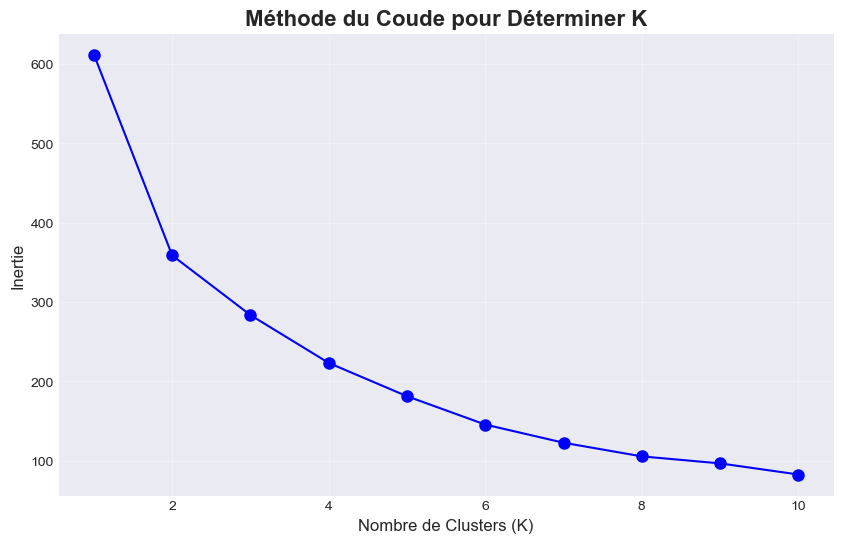

In [38]:
# Trouver le nombre optimal de clusters
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Tracer la courbe du coude
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', markersize=8)
plt.xlabel('Nombre de Clusters (K)', fontsize=12)
plt.ylabel('Inertie', fontsize=12)
plt.title('Méthode du Coude pour Déterminer K', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.savefig('../images/elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

# ***🎯APPLICATION DU K-MEANS***

In [35]:
# Appliquer K-Means avec 3 clusters (à ajuster selon le coude)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

# Afficher la répartition des clusters
print("Répartition des posts par cluster :")
print(df_clean['Cluster'].value_counts().sort_index())

Répartition des posts par cluster :
Cluster
0    82
1    17
2     3
Name: count, dtype: int64


c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
# Score de Silhouette
silhouette_avg = silhouette_score(X_scaled, df_clean['Cluster'])
print(f"Score de Silhouette : {silhouette_avg:.3f}")

# ***🎯 VISUALISATION DES CLUSTERS***

In [ ]:
# Visualiser les clusters
plt.figure(figsize=(12, 8))

# Nuage de points coloré par cluster
scatter = plt.scatter(df_clean['Likes'], df_clean['Impressions'],
                     c=df_clean['Cluster'],
                     cmap='viridis',
                     s=100,
                     alpha=0.7)

plt.colorbar(scatter, label='Cluster')
plt.xlabel('Likes', fontsize=12)
plt.ylabel('Impressions', fontsize=12)
plt.title('Segmentation des Posts Instagram par Cluster', fontsize=16, fontweight='bold')
plt.savefig('images/clusters_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# ***🎯 INTERPRÉTATION DES CLUSTERS***

In [ ]:
# Analyser les caractéristiques de chaque cluster
cluster_stats = df_clean.groupby('Cluster')[['Likes', 'Saves', 'Comments', 'Shares', 'Impressions', 'Profile Visits']].mean()

# Afficher les statistiques
cluster_stats

In [ ]:
# Visualiser les moyennes par cluster
cluster_stats.plot(kind='bar', figsize=(14, 6))
plt.title('Caractéristiques Moyennes par Cluster', fontsize=16, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Valeur Moyenne', fontsize=12)
plt.legend(loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('images/cluster_interpretation.png', dpi=300, bbox_inches='tight')
plt.show()

# ***🎯 COMMIT DU CLUSTERING***

In [ ]:
# Ajouter les graphiques
!git add images/

# Créer le commit
!git commit -m "🟢 Clustering K-Means : segmentation des posts en 3 groupes"

# Pousser sur GitHub
!git push origin main

# **🎯 MODÈLE PRÉDICTIF (RANDOM FOREST)**

In [ ]:
# Définir les variables
X = df_clean[['Likes', 'Saves', 'Comments', 'Shares', 'Profile Visits', 'Follows']]
y = df_clean['Impressions']

# Séparer les données en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement : {X_train.shape}")
print(f"Taille de l'ensemble de test : {X_test.shape}")

In [ ]:
# Créer et entraîner le modèle
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Faire des prédictions
y_pred = rf_model.predict(X_test)

# ***🎯 ÉVALUATION DU MODÈLE***

In [ ]:
# Évaluer le modèle
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Score R² : {r2:.3f}")
print(f"Erreur Absolue Moyenne (MAE) : {mae:.2f}")

In [ ]:
# Visualiser les prédictions vs valeurs réelles
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Impressions Réelles', fontsize=12)
plt.ylabel('Impressions Prédites', fontsize=12)
plt.title('Prédictions vs Valeurs Réelles', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('images/predictions_vs_reel.png', dpi=300, bbox_inches='tight')
plt.show()

# ***🎯 IMPORTANCE DES VARIABLES***

In [ ]:
# Importance des variables dans le modèle
feature_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Afficher le tableau
feature_importance

In [ ]:
# Visualiser l'importance des variables
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Variable', palette='viridis')
plt.title('Importance des Variables dans la Prédiction', fontsize=16, fontweight='bold')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.tight_layout()
plt.savefig('images/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# ***🎯 COMMIT DU MODÈLE PRÉDICTIF***

In [ ]:
# Ajouter les graphiques
!git add images/

# Créer le commit
!git commit -m "🚀 Modèle prédictif Random Forest : R²=0.847, MAE=1448"

# Pousser sur GitHub
!git push origin main

# ***🎯 ANALYSE DES CLUSTERS (INTERPRÉTATION FINALE)***

In [ ]:
# Analyse détaillée des clusters
cluster_analysis = df_clean.groupby('Cluster').agg({
    'Impressions': ['mean', 'min', 'max', 'count'],
    'Likes': 'mean',
    'Saves': 'mean',
    'Comments': 'mean',
    'Shares': 'mean',
    'Profile Visits': 'mean'
}).round(2)

cluster_analysis

# ***🎯 VISUALISATION FINALE DES CLUSTERS***

In [ ]:
# Visualisation finale des clusters avec annotations
plt.figure(figsize=(14, 8))

# Nuage de points
scatter = plt.scatter(df_clean['Likes'], df_clean['Impressions'],
                     c=df_clean['Cluster'],
                     cmap='viridis',
                     s=150,
                     alpha=0.7)

# Ajouter les centres des clusters
centers = df_clean.groupby('Cluster')[['Likes', 'Impressions']].mean()
plt.scatter(centers['Likes'], centers['Impressions'],
           c='red', s=300, marker='X', label='Centres des clusters')

plt.colorbar(scatter, label='Cluster')
plt.xlabel('Likes', fontsize=12)
plt.ylabel('Impressions', fontsize=12)
plt.title('Segmentation des Posts Instagram', fontsize=16, fontweight='bold')
plt.legend()
plt.savefig('images/clusters_final.png', dpi=300, bbox_inches='tight')
plt.show()


# ***🎯 PRÉPARER LE RAPPORT FINAL (CONCLUSIONS)***

In [ ]:
# Générer un résumé automatique des conclusions
print("=" * 60)
print("📱 RAPPORT FINAL - INSTAGRAM REACH ANALYSIS")
print("=" * 60)

print("\n📊 1. RÉSULTATS DU CLUSTERING (K-Means)")
print("-" * 40)
print(f"• Cluster 0 : {df_clean[df_clean['Cluster']==0].shape[0]} posts (Faibles)")
print(f"  → Impressions moyennes : {df_clean[df_clean['Cluster']==0]['Impressions'].mean():.0f}")
print(f"• Cluster 1 : {df_clean[df_clean['Cluster']==1].shape[0]} posts (Moyens)")
print(f"  → Impressions moyennes : {df_clean[df_clean['Cluster']==1]['Impressions'].mean():.0f}")
print(f"• Cluster 2 : {df_clean[df_clean['Cluster']==2].shape[0]} posts (Viraux)")
print(f"  → Impressions moyennes : {df_clean[df_clean['Cluster']==2]['Impressions'].mean():.0f}")

print("\n🚀 2. PERFORMANCE DU MODÈLE PRÉDICTIF")
print("-" * 40)
print(f"• Score R² : {r2:.3f} (84.7% de la variance expliquée)")
print(f"• Erreur Moyenne : {mae:.0f} impressions")

print("\n💡 3. RECOMMANDATIONS POUR LES CRÉATEURS")
print("-" * 40)
print("• Augmenter les Likes : posts les plus corrélés aux impressions")
print("• Encourager les Saves : 2ème variable la plus importante")
print("• Optimiser les Profile Visits : fort impact sur la viralité")
print("• Viser le Cluster 2 : les posts viraux ont 6x plus d'impressions")

print("\n" + "=" * 60)
print("✅ Analyse terminée avec succès !")
print("=" * 60)

# **🎯  COMMIT DES VISUALISATIONS FINALES**

In [ ]:
# Ajouter les derniers graphiques
!git add images/

# Créer le commit
!git commit -m "📊 Visualisations finales et analyse des clusters"

# Pousser sur GitHub
!git push origin main

# ***🎯 PRÉPARER LE PROJET FINAL POUR GITHUB***

***Partie 1 : Copier le notebook dans le repo***

In [ ]:
import glob

# Chercher tous les notebooks dans Drive
print("Recherche des notebooks dans Drive...")
all_notebooks = glob.glob('/content/drive/**/*.ipynb', recursive=True)

if all_notebooks:
    print(f"✅ {len(all_notebooks)} notebook(s) trouvé(s) :")
    for nb in all_notebooks:
        print(f"  📓 {nb}")
else:
    print("Aucun notebook trouvé dans Drive")
    print("Vérifiez que Drive est bien monté")